In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
sim_df = pd.read_csv('/content/simulation.csv')

In [30]:
sim_df

,id,date,store,item,predicted_demand,historical_mean,demand_std,lead_time_demand,safety_stock,reorder_point,current_inventory,inventory_position,recommended_order_qty,calculated_initial_inventory,opening_inventory,inventory_after_demand,on_order,order_quantity,arrival_date
0,0,2018-01-01,1,1,13.28,20.04,6.57,114.60,28.57,143.17,140.28,127.000000,3,140.28,140.280000,127.000000,0.0,17.0,2018-01-08
1,1,2018-01-02,1,1,15.33,20.04,6.57,114.50,28.57,143.07,140.28,128.670000,3,140.28,127.000000,111.670000,17.0,15.0,2018-01-09
2,2,2018-01-03,1,1,15.24,20.04,6.57,114.49,28.57,143.06,140.28,128.430001,3,140.28,111.670000,96.430001,32.0,15.0,2018-01-10
3,3,2018-01-04,1,1,15.78,20.04,6.57,114.58,28.57,143.15,140.28,127.650001,3,140.28,96.430001,80.650001,47.0,16.0,2018-01-11
4,4,2018-01-05,1,1,16.81,20.04,6.57,114.71,28.57,143.28,140.28,126.840001,3,140.28,80.650001,63.840001,63.0,17.0,2018-01-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,44995,2018-03-27,10,50,75.06,74.36,19.35,520.50,84.21,604.71,520.52,529.909980,84,520.52,159.969978,84.909980,445.0,75.0,2018-04-03
44996,44996,2018-03-28,10,50,74.30,74.36,19.35,520.50,84.21,604.71,520.52,530.609977,84,520.52,158.909980,84.609977,446.0,75.0,2018-04-04
44997,44997,2018-03-29,10,50,79.76,74.36,19.35,520.50,84.21,604.71,520.52,525.849975,84,520.52,164.609977,84.849975,441.0,79.0,2018-04-05
44998,44998,2018-03-30,10,50,84.23,74.36,19.35,520.50,84.21,604.71,520.52,520.619972,84,520.52,168.849975,84.619972,436.0,85.0,2018-04-06


In [31]:
sim_df['cycle_stock'] = (
    sim_df['historical_mean'] * 7
)

sim_df['target_inventory'] = (
    sim_df['lead_time_demand']
    + sim_df['safety_stock']
    + sim_df['cycle_stock']
)

In [32]:
sim_df['recommended_order_qty'] = np.ceil(
    sim_df['target_inventory'] -
    sim_df['inventory_position']
)

In [33]:
sim_df['opening_inventory'] = 0.0
sim_df['inventory_after_demand'] = 0.0
sim_df['on_order'] = 0.0
sim_df['inventory_position'] = 0.0
sim_df['order_quantity'] = 0.0
sim_df['arrival_date'] = pd.NaT

In [35]:
# ============================================================
# 1. SETTINGS
# ============================================================

lead_time = 7

# Make sure date is datetime
sim_df['date'] = pd.to_datetime(sim_df['date'])


# ============================================================
# 2. INITIALIZE SIMULATION COLUMNS
# ============================================================

sim_df['opening_inventory'] = 0.0
sim_df['inventory_after_demand'] = 0.0
sim_df['on_order'] = 0.0
sim_df['inventory_position'] = 0.0

sim_df['order_quantity'] = 0.0
sim_df['recommended_order_qty'] = 0.0

sim_df['arrival_date'] = pd.NaT


# ============================================================
# 3. SORT DATA
# ============================================================

sim_df = sim_df.sort_values(
    ['store', 'item', 'date']
).reset_index(drop=True)


# ============================================================
# 4. INVENTORY SIMULATION
# ============================================================

for (store, item), group in sim_df.groupby(['store', 'item']):

    # --------------------------------------------------------
    # Initial inventory for this store-item
    # --------------------------------------------------------

    inventory = group.iloc[0]['calculated_initial_inventory']

    # Store orders that have not arrived yet
    pending_orders = []


    # --------------------------------------------------------
    # Daily simulation
    # --------------------------------------------------------

    for idx in group.index:

        current_date = sim_df.loc[idx, 'date']


        # ====================================================
        # STEP 1: RECEIVE ORDERS ARRIVING TODAY
        # ====================================================

        received = sum(
            order['quantity']
            for order in pending_orders
            if order['arrival_date'] == current_date
        )

        inventory += received


        # Remove received orders from pending list
        pending_orders = [
            order
            for order in pending_orders
            if order['arrival_date'] != current_date
        ]


        # ====================================================
        # STEP 2: OPENING INVENTORY
        # ====================================================

        sim_df.loc[idx, 'opening_inventory'] = inventory


        # ====================================================
        # STEP 3: SUBTRACT TODAY'S PREDICTED DEMAND
        # ====================================================

        demand = sim_df.loc[idx, 'predicted_demand']

        inventory -= demand

        sim_df.loc[idx, 'inventory_after_demand'] = inventory


        # ====================================================
        # STEP 4: CALCULATE ON-ORDER INVENTORY
        # ====================================================

        on_order = sum(
            order['quantity']
            for order in pending_orders
        )

        sim_df.loc[idx, 'on_order'] = on_order


        # ====================================================
        # STEP 5: INVENTORY POSITION
        # ====================================================

        inventory_position = (
            inventory + on_order
        )

        sim_df.loc[idx, 'inventory_position'] = (
            inventory_position
        )


        # ====================================================
        # STEP 6: GET ROP AND TARGET INVENTORY
        # ====================================================

        rop = sim_df.loc[idx, 'reorder_point']

        target = sim_df.loc[idx, 'target_inventory']


        # ====================================================
        # STEP 7: CALCULATE RECOMMENDED ORDER QUANTITY
        # ====================================================

        recommended_order_qty = max(
            0,
            np.ceil(
                target - inventory_position
            )
        )


        # ====================================================
        # STEP 8: CHECK REORDER POINT
        # ====================================================

        if (
            inventory_position < rop
            and recommended_order_qty > 0
        ):

            # Calculate arrival date
            arrival_date = (
                current_date
                + pd.Timedelta(days=lead_time)
            )


            # Add order to pending orders
            pending_orders.append({
                'quantity': recommended_order_qty,
                'arrival_date': arrival_date
            })


            # Save order information
            sim_df.loc[idx, 'order_quantity'] = (
                recommended_order_qty
            )

            sim_df.loc[idx, 'recommended_order_qty'] = (
                recommended_order_qty
            )

            sim_df.loc[idx, 'arrival_date'] = (
                arrival_date
            )


# ============================================================
# 5. CREATE FINAL RESULT TABLE
# ============================================================

result = sim_df[
    [
        'date',
        'store',
        'item',
        'predicted_demand',
        'opening_inventory',
        'inventory_after_demand',
        'on_order',
        'inventory_position',
        'reorder_point',
        'target_inventory',
        'recommended_order_qty',
        'arrival_date'
    ]
]


# ============================================================
# 6. DISPLAY RESULT
# ============================================================

result.head(20)

,date,store,item,predicted_demand,opening_inventory,inventory_after_demand,on_order,inventory_position,reorder_point,target_inventory,recommended_order_qty,arrival_date
0,2018-01-01,1,1,13.28,140.28,127.00,0.0,127.00,143.17,283.45,157.0,2018-01-08
1,2018-01-02,1,1,15.33,127.00,111.67,157.0,268.67,143.07,283.35,0.0,NaT
2,2018-01-03,1,1,15.24,111.67,96.43,157.0,253.43,143.06,283.34,0.0,NaT
3,2018-01-04,1,1,15.78,96.43,80.65,157.0,237.65,143.15,283.43,0.0,NaT
4,2018-01-05,1,1,16.81,80.65,63.84,157.0,220.84,143.28,283.56,0.0,NaT
5,2018-01-06,1,1,18.23,63.84,45.61,157.0,202.61,143.98,284.26,0.0,NaT
6,2018-01-07,1,1,20.00,45.61,25.61,157.0,182.61,143.91,284.19,0.0,NaT
7,2018-01-08,1,1,13.22,182.61,169.39,0.0,169.39,143.95,284.23,0.0,NaT
8,2018-01-09,1,1,15.23,169.39,154.16,0.0,154.16,143.65,283.93,0.0,NaT
9,2018-01-10,1,1,15.23,154.16,138.93,0.0,138.93,143.51,283.78,145.0,2018-01-17


In [36]:
print("Total orders:",
      (sim_df['recommended_order_qty'] > 0).sum())

print("Total units ordered:",
      sim_df['recommended_order_qty'].sum())

Total orders: 5953
Total units ordered: 2357286.0


In [37]:
print("Minimum inventory:",
      sim_df['inventory_after_demand'].min())

print("Negative inventory rows:",
      (sim_df['inventory_after_demand'] < 0).sum())

print("Zero inventory rows:",
      (sim_df['inventory_after_demand'] == 0).sum())

Minimum inventory: 10.56000000000002
Negative inventory rows: 0
Zero inventory rows: 0


In [38]:
order_rows = sim_df[
    sim_df['recommended_order_qty'] > 0
].copy()

order_rows['days_to_arrival'] = (
    order_rows['arrival_date'] - order_rows['date']
).dt.days

order_rows['days_to_arrival'].value_counts()

,count
days_to_arrival,
7,5953


In [39]:
order_summary = (
    sim_df[sim_df['recommended_order_qty'] > 0]
    .groupby(['store', 'item'])
    .agg(
        number_of_orders=('recommended_order_qty', 'count'),
        total_units_ordered=('recommended_order_qty', 'sum')
    )
    .reset_index()
)

order_summary.head(20)

,store,item,number_of_orders,total_units_ordered
0,1,1,12,1818.0
1,1,2,12,4973.0
2,1,3,12,2947.0
3,1,4,12,1802.0
4,1,5,12,1519.0
5,1,6,12,4917.0
6,1,7,12,4730.0
7,1,8,12,6270.0
8,1,9,12,4197.0
9,1,10,12,6100.0


In [40]:
invalid_orders = sim_df[
    (sim_df['recommended_order_qty'] > 0) &
    (sim_df['inventory_position'] >= sim_df['reorder_point'])
]

print("Invalid orders:", len(invalid_orders))

Invalid orders: 0


In [41]:
print("Store-item combinations:", len(order_summary))
print("Total orders:", order_summary['number_of_orders'].sum())
print("Total units ordered:", order_summary['total_units_ordered'].sum())

Store-item combinations: 500
Total orders: 5953
Total units ordered: 2357286.0


In [42]:
print("Average inventory:",
      sim_df['inventory_after_demand'].mean())

print("Maximum inventory:",
      sim_df['inventory_after_demand'].max())

Average inventory: 257.560586
Maximum inventory: 915.9699999999998


In [43]:
print("Total rows:", len(sim_df))
print("Store-item combinations:",
      sim_df[['store', 'item']].drop_duplicates().shape[0])

Total rows: 45000
Store-item combinations: 500


In [44]:
dashboard_df = sim_df[
    [
        'date',
        'store',
        'item',
        'predicted_demand',
        'opening_inventory',
        'inventory_after_demand',
        'inventory_position',
        'reorder_point',
        'target_inventory',
        'recommended_order_qty',
        'arrival_date'
    ]
].copy()

dashboard_df.head()

,date,store,item,predicted_demand,opening_inventory,inventory_after_demand,inventory_position,reorder_point,target_inventory,recommended_order_qty,arrival_date
0,2018-01-01,1,1,13.28,140.28,127.00,127.00,143.17,283.45,157.0,2018-01-08
1,2018-01-02,1,1,15.33,127.00,111.67,268.67,143.07,283.35,0.0,NaT
2,2018-01-03,1,1,15.24,111.67,96.43,253.43,143.06,283.34,0.0,NaT
3,2018-01-04,1,1,15.78,96.43,80.65,237.65,143.15,283.43,0.0,NaT
4,2018-01-05,1,1,16.81,80.65,63.84,220.84,143.28,283.56,0.0,NaT


In [45]:
total_store_items = dashboard_df[['store', 'item']].drop_duplicates().shape[0]

total_orders = (dashboard_df['recommended_order_qty'] > 0).sum()

total_units_ordered = dashboard_df['recommended_order_qty'].sum()

average_inventory = dashboard_df['inventory_after_demand'].mean()

minimum_inventory = dashboard_df['inventory_after_demand'].min()

print("Total Store-Item Combinations:", total_store_items)
print("Total Orders:", total_orders)
print("Total Units Ordered:", total_units_ordered)
print("Average Inventory:", round(average_inventory, 2))
print("Minimum Inventory:", round(minimum_inventory, 2))

Total Store-Item Combinations: 500
Total Orders: 5953
Total Units Ordered: 2357286.0
Average Inventory: 257.56
Minimum Inventory: 10.56


In [46]:
daily_inventory = (dashboard_df.groupby('date')['inventory_after_demand'].sum())
daily_inventory = daily_inventory.reset_index()
daily_inventory.head()

,date,inventory_after_demand
0,2018-01-01,166561.03
1,2018-01-02,146503.66
2,2018-01-03,126564.26
3,2018-01-04,104856.27
4,2018-01-05,81766.92


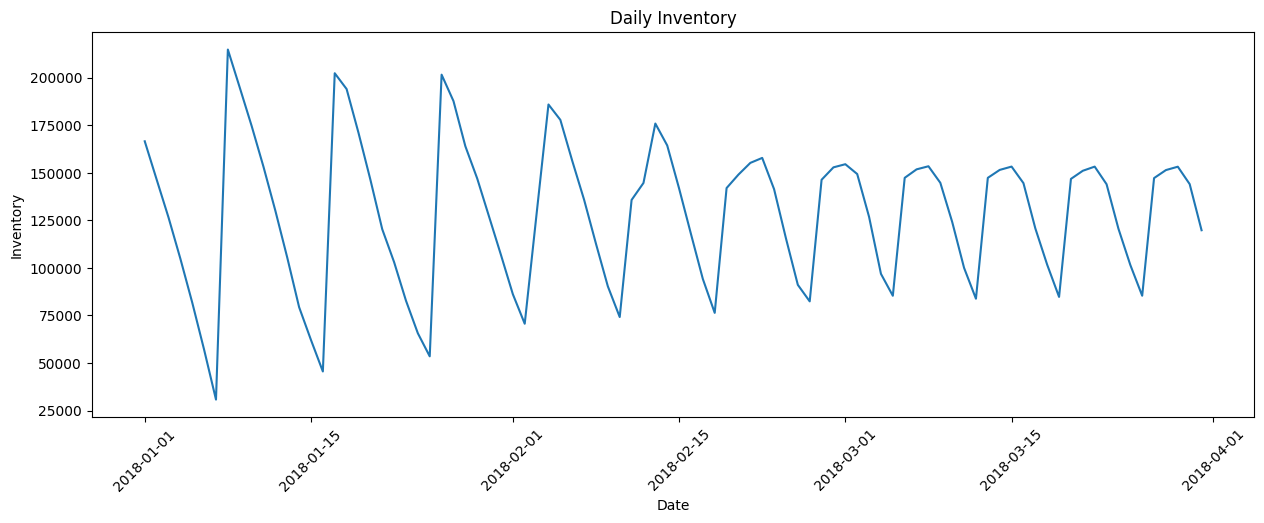

In [47]:
plt.figure(figsize=(15,5))
plt.plot(daily_inventory['date'], daily_inventory['inventory_after_demand'])
plt.xlabel('Date')
plt.ylabel('Inventory')
plt.title('Daily Inventory')

plt.xticks(rotation=45)
plt.show()

In [48]:
avg_inventory = (dashboard_df.groupby('store')['inventory_after_demand'].mean())

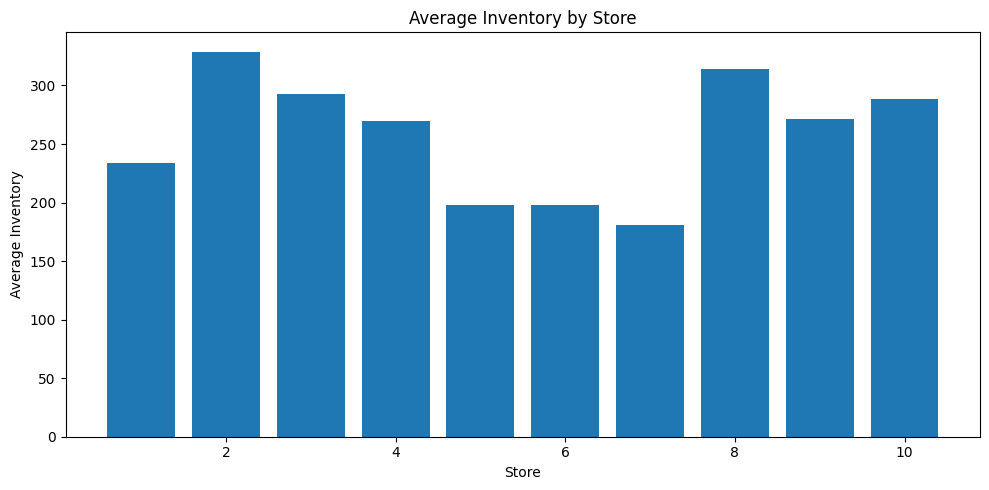

In [49]:
plt.figure(figsize=(10,5))
plt.bar(avg_inventory.index, avg_inventory.values)
plt.xlabel('Store')
plt.ylabel('Average Inventory')
plt.title('Average Inventory by Store')
plt.tight_layout()

plt.show()

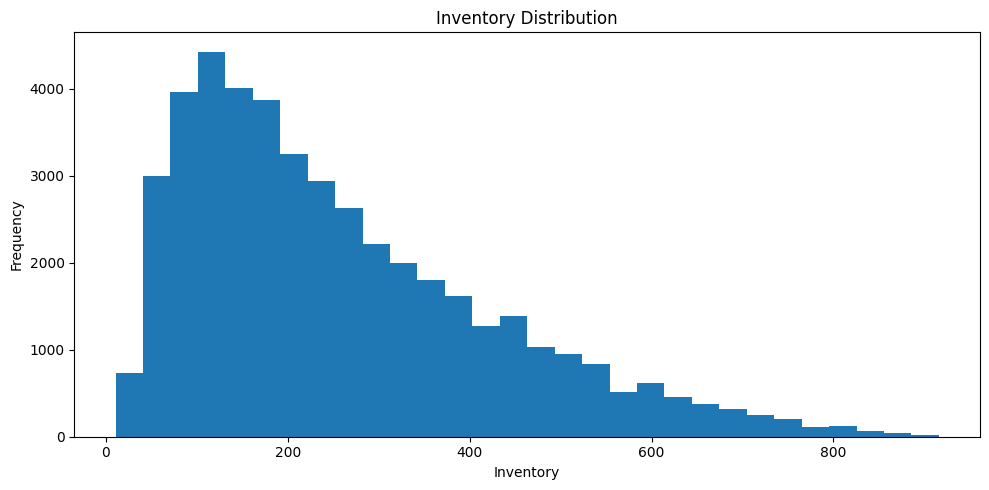

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(
    dashboard_df['inventory_after_demand'],
    bins=30
)

plt.xlabel('Inventory')
plt.ylabel('Frequency')
plt.title('Inventory Distribution')

plt.tight_layout()
plt.show()

In [51]:
orders_by_store = (sim_df[sim_df['recommended_order_qty'] > 0].groupby('store').agg(
                  total_orders=('recommended_order_qty', 'count'),
                  total_units_ordered=('recommended_order_qty', 'sum')).reset_index() )

orders_by_store.head(10)

,store,total_orders,total_units_ordered
0,1,598,214395.0
1,2,596,300412.0
2,3,598,269151.0
3,4,599,249895.0
4,5,590,178535.0
5,6,595,179282.0
6,7,590,164086.0
7,8,595,287942.0
8,9,595,248733.0
9,10,597,264855.0


In [52]:
top_store_items = (order_summary.sort_values('total_units_ordered', ascending=False).head(10).reset_index(drop=True))

top_store_items

,store,item,number_of_orders,total_units_ordered
0,2,15,12,10157.0
1,2,18,12,9617.0
2,2,28,11,9399.0
3,2,45,12,9336.0
4,8,13,12,9329.0
5,2,38,12,9227.0
6,2,22,12,9175.0
7,2,25,12,9156.0
8,8,15,11,9028.0
9,8,28,11,8987.0


In [53]:
orders_by_item = (
    sim_df[sim_df['recommended_order_qty'] > 0]
    .groupby('item')
    .agg(
        total_orders=('recommended_order_qty', 'count'),
        total_units_ordered=('recommended_order_qty', 'sum')
    )
    .reset_index()
)

orders_by_item.head(10)

,item,total_orders,total_units_ordered
0,1,120,19897.0
1,2,120,53415.0
2,3,120,33518.0
3,4,118,19792.0
4,5,118,16546.0
5,6,119,52529.0
6,7,120,53317.0
7,8,120,69488.0
8,9,120,46927.0
9,10,120,66023.0


In [54]:
recommended_orders = sim_df[
    sim_df['recommended_order_qty'] > 0
][
    [
        'date',
        'store',
        'item',
        'inventory_position',
        'reorder_point',
        'target_inventory',
        'recommended_order_qty',
        'arrival_date'
    ]
].copy()

recommended_orders.head(10)

,date,store,item,inventory_position,reorder_point,target_inventory,recommended_order_qty,arrival_date
0,2018-01-01,1,1,127.00,143.17,283.45,157.0,2018-01-08
9,2018-01-10,1,1,138.93,143.51,283.78,145.0,2018-01-17
18,2018-01-19,1,1,136.07,145.64,285.92,150.0,2018-01-26
26,2018-01-27,1,1,149.29,149.49,289.76,141.0,2018-02-03
34,2018-02-04,1,1,147.87,154.73,295.00,148.0,2018-02-11
43,2018-02-13,1,1,138.64,154.19,294.46,156.0,2018-02-20
52,2018-02-22,1,1,135.09,154.84,295.11,161.0,2018-03-01
59,2018-03-01,1,1,169.83,177.33,317.61,148.0,2018-03-08
66,2018-03-08,1,1,169.08,178.90,319.18,151.0,2018-03-15
73,2018-03-15,1,1,169.77,179.14,319.42,150.0,2018-03-22
